In [2]:
import cv2
import copy
import os
import pickle
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [3]:
# set params
image_path = "../data/calibr_dataset/WIN_20260520_12_20_05_Pro.jpg"
calibr_file_path = "../data/calibration.pckl"

boardSize = (9, 6)
frSize = (1600, 1200)
cell_size = 22   # chessboard cell size in mm
# cell_size_px = 100   # chessboard cell size in pixels

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

In [4]:
def show_image(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    plt.imshow(image)
    plt.title(Path(image_path).stem)
    plt.axis('off')

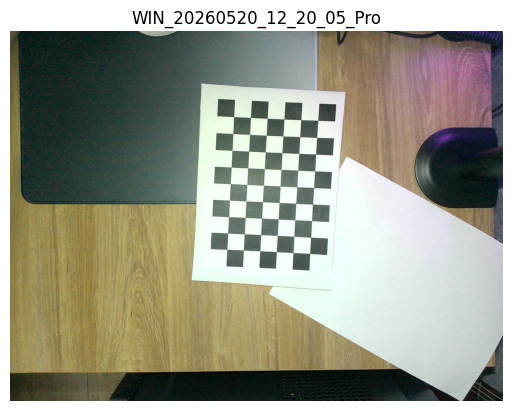

In [5]:
show_image(image_path)

In [6]:
def get_undistored_image(image_path, calibr_file_path):
    
    if not os.path.exists(calibr_file_path):
        raise FileNotFoundError(f"[WARKING] Calibration file not found: {calibr_file_path}")

    with open(calibr_file_path, "rb") as f:
        calibr_results = pickle.load(f)
        
    mtx = calibr_results["mtx"]
    opt_mtx = calibr_results["opt_mtx"]
    dist = calibr_results["dist"]    
    
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    image_undistorted = cv2.undistort(
        image, mtx, dist, None, opt_mtx,
    )
    
    _, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(image)
    axes[0].set_title(f"{Path(image_path).stem}_original")
    axes[0].axis("off")

    axes[1].imshow(image_undistorted)
    axes[1].set_title(f"{Path(image_path).stem}_undistorted")
    axes[1].axis("off")
    
    return image_undistorted

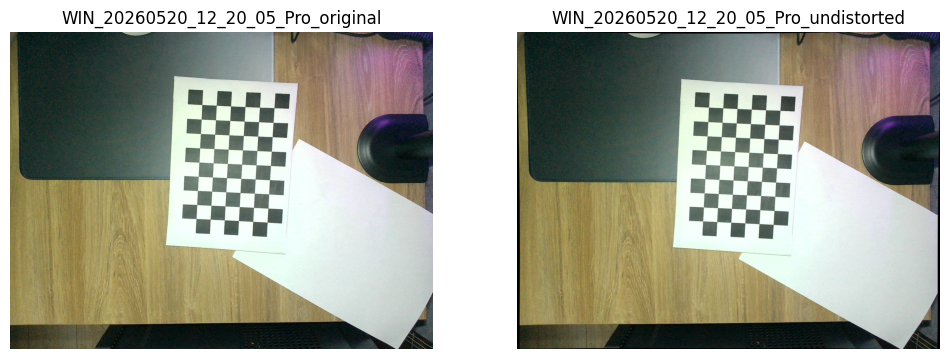

In [7]:
image_undistorted = get_undistored_image(image_path, calibr_file_path)

In [8]:
def find_board_corners(image, board_size, criteria):
    
    image_cr = copy.deepcopy(image)
    image_gray = cv2.cvtColor(image_cr, cv2.COLOR_RGB2GRAY)
    
    # find board corners
    ret, corners = cv2.findChessboardCorners(
        image_gray, 
        board_size, 
        cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE,
    )
    
    if ret:
        corners2 = cv2.cornerSubPix(
            image_gray, 
            corners, 
            (11,11),
            (-1,-1), 
            criteria,
        )
    else:
        raise ValueError("[WARNING] Chessboard corners not found in image!")
    
    image = cv2.drawChessboardCorners(
        image_cr, 
        board_size, 
        corners2, 
        ret,
    )

    plt.imshow(image_cr)
    plt.title(f"{Path(image_path).stem}_corners")
    plt.axis('off')
    
    corners2 = corners2.reshape(-1, 2).astype(np.float32)
    
    return corners2

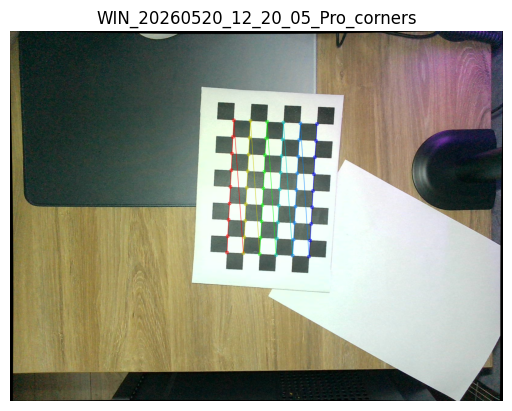

In [9]:
corners = find_board_corners(image_undistorted, boardSize, criteria)

In [10]:
# def get_dest_points(board_size, cell_size_px):
#     dest_pts = np.mgrid[0:board_size[0], 0:board_size[1]].T.reshape(-1, 2).astype(np.float32)
#     dest_pts *= cell_size_px
    
#     return dest_pts

def get_dest_points(board_size, cell_size):
    
    width, height = board_size
    
    dst_list = []
    
    for r in range(height):
        for c in range(width):
            x = c * cell_size
            y = r * cell_size
            dst_list.append([x, y])
            
    dest_pts = np.array(dst_list, dtype=np.float32)
    
    return dest_pts

In [11]:
def homography_processing(corners, dest_pts):
    H, _ = cv2.findHomography(
        corners,
        dest_pts,
        cv2.RANSAC
    )
    
    return H

In [12]:
dest_pts = get_dest_points(boardSize, cell_size)
H = homography_processing(corners, dest_pts)

print(f"len corners: {len(corners)}")
print(f"len dest_pts: {len(dest_pts)}")

len corners: 54
len dest_pts: 54


In [371]:
def warp_perspective(undistored_image, board_size, cell_size_px, h):
    
    dst_w = (board_size[0] - 1) * cell_size_px
    dst_h = (board_size[1] - 1) * cell_size_px
    
    warped_image = cv2.warpPerspective(
        undistored_image,
        h,
        (1800, 2500),
    )
    
    _, axes = plt.subplots(1, 2, figsize=(12, 6))

    # print(warped_image)

    axes[0].imshow(undistored_image)
    axes[0].set_title(f"{Path(image_path).stem}_undistorted")
    axes[0].axis("off")

    axes[1].imshow(warped_image)
    axes[1].set_title(f"{Path(image_path).stem}_warped")
    axes[1].axis("off")

In [372]:
# warp_perspective(image_undistorted, boardSize, cell_size_px, H)

In [14]:
def save_homography_matrix(h, save_mtx_path):
    
    pcl_dict = {
        "h_mtx": h,
    }
    
    with open(save_mtx_path, "wb") as f:
        pickle.dump(pcl_dict, f)
        
    print(f"[INFO] Homography matrix saved to: {save_mtx_path}")

In [15]:
save_mtx_path = "../data/h_mtx.pckl"
save_homography_matrix(H, save_mtx_path)

[INFO] Homography matrix saved to: ../data/h_mtx.pckl
